In [1]:
#Importar el Dataframe

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)

print(housing.DESCR)

df = housing.frame
df

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


**Parte 1**

a) Limpieza de datos.

b) Análisis exploratorio de datos (EDA).

**Parte 2**

Correr un modelo de regresión lineal para predecir el valor de *MedHouseVal*.

**Parte 3**

Extraer conclusiones de la predicción y presentar los resultados.

# Parte 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


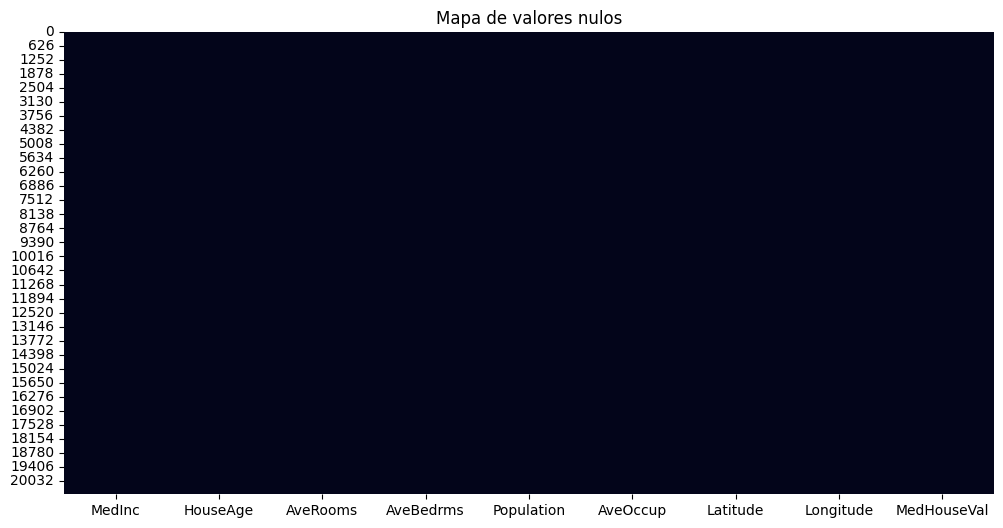

In [3]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

### no hay valores nulos


In [4]:
print(f"Tenemos {df.duplicated().sum()} filas duplicadas")

Tenemos 0 filas duplicadas


In [5]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [6]:

df = df.drop('Longitude', axis=1)
df = df.drop('Latitude', axis=1)
df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,3.422
...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,0.847


0    52.0
Name: HouseAge, dtype: float64


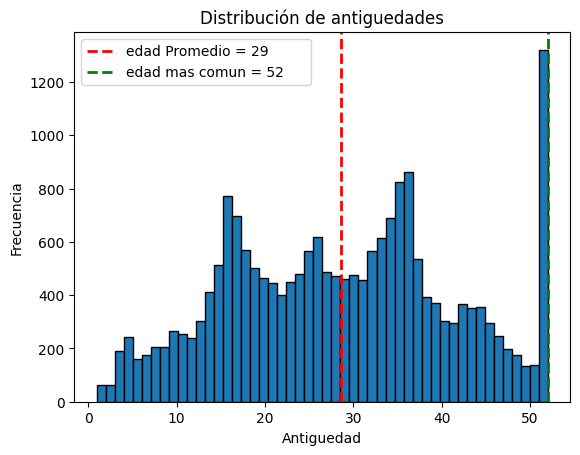

In [7]:
plt.hist(df['HouseAge'].dropna(), bins=50, edgecolor='k')
plt.title("Distribución de antiguedades")
plt.xlabel("Antiguedad")
plt.ylabel("Frecuencia")
valor_marcar = df['HouseAge'].mean()
plt.xticks(rotation = 0)
plt.axvline(x=valor_marcar, color='red', linestyle='--', linewidth=2, label=f"edad Promedio = {valor_marcar:.0f}     ")
valor_marcar2 = df['HouseAge'].mode()
print(valor_marcar2)
plt.xticks(rotation = 0)
plt.axvline(x=valor_marcar2[0], color='green', linestyle='--', linewidth=2, label=f"edad mas comun = {valor_marcar2[0]:.0f}     ")
plt.legend()
plt.show()

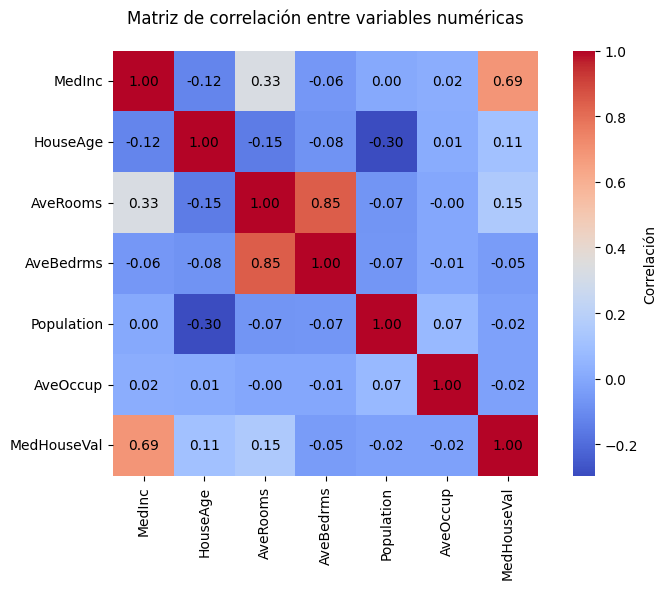

In [8]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"label": "Correlación"},
            annot_kws={"size": 10, "color": "black"})
plt.title("Matriz de correlación entre variables numéricas", pad=20)
plt.tight_layout()
plt.show()


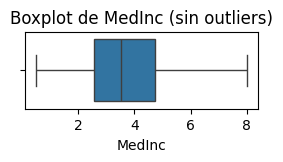

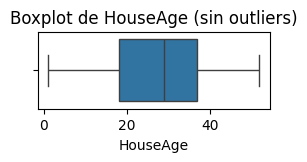

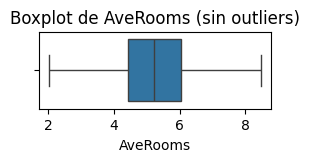

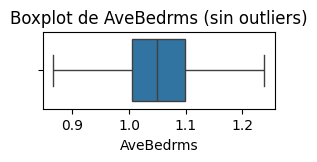

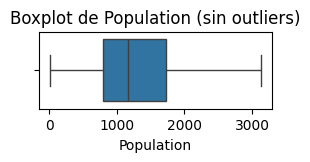

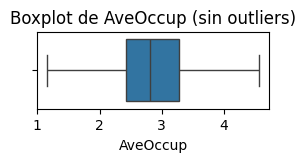

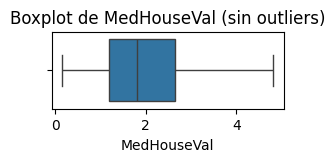

In [9]:
cols = df.columns
for col in cols:
    plt.figure(figsize=(3,1), )
    sns.boxplot(x=df[col], showfliers= False)
    plt.title(f"Boxplot de {col} (sin outliers)")
    plt.show()

In [10]:
valorRaro = df['MedHouseVal'].mode()
df_filtrado = df[df['MedHouseVal']!= valorRaro[0]]
df_filtrado = df_filtrado[df_filtrado['AveRooms']< 15]
muestra = df_filtrado.sample(n=500)
print(valorRaro)
muestra

0    5.00001
Name: MedHouseVal, dtype: float64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,MedHouseVal
20408,7.7889,26.0,8.730038,1.045627,842.0,3.201521,3.099
6377,3.6000,44.0,6.094086,1.145161,980.0,2.634409,3.074
7392,2.3864,42.0,5.139535,1.143411,918.0,3.558140,0.988
6016,2.4464,33.0,3.520000,0.906667,964.0,3.213333,1.287
10776,4.4135,30.0,4.773913,1.056522,1131.0,2.458696,2.723
...,...,...,...,...,...,...,...
15426,3.4456,5.0,4.650000,1.101724,1633.0,2.815517,1.658
15475,2.2278,15.0,4.618582,0.899756,754.0,1.843521,1.328
7276,1.5272,41.0,4.614583,1.133333,2054.0,4.279167,1.003
9477,3.5880,32.0,5.803758,0.981211,1281.0,2.674322,0.960


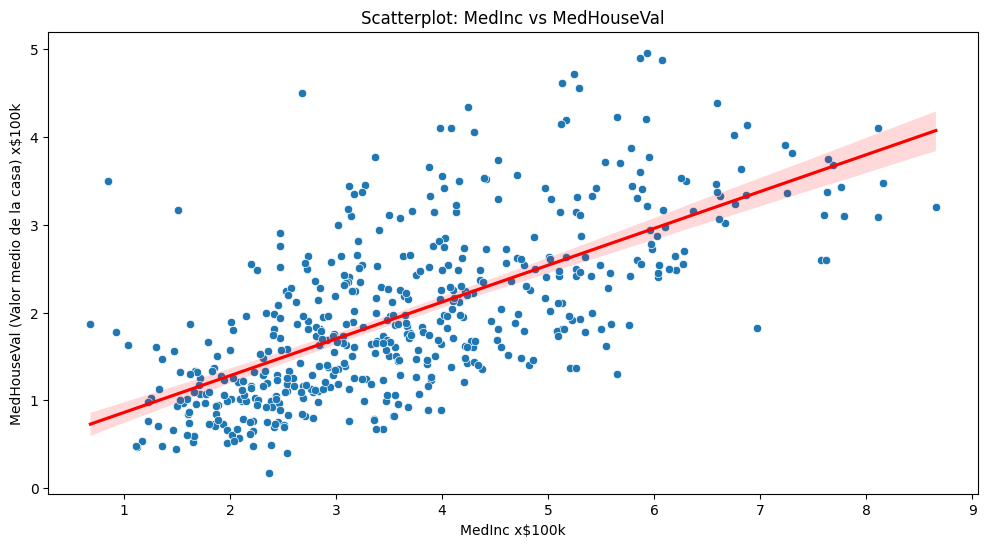

In [11]:
plt.figure(figsize=(12,6))
sns.scatterplot(x="MedInc", y="MedHouseVal", data=muestra , alpha=1)
sns.regplot(x="MedInc", y="MedHouseVal", data=muestra , scatter=False, color="red")
plt.title("Scatterplot: MedInc vs MedHouseVal")
plt.xlabel("MedInc x$100k")
plt.ylabel("MedHouseVal (Valor medio de la casa) x$100k")
plt.show()

<Axes: xlabel='AveRooms', ylabel='AveBedrms'>

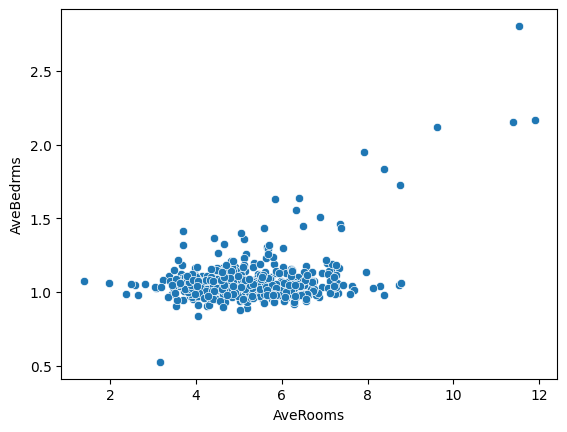

In [12]:
sns.scatterplot(x="AveRooms", y="AveBedrms", data=muestra, alpha=1)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
y = df[["MedHouseVal"]]
X = df.drop(columns=["MedHouseVal"])
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2)
reg = LinearRegression()
reg.fit(X_train,Y_train)
estimated = [reg.intercept_, reg.coef_]
print(estimated)

[array([-0.3533]), array([[ 5.43019862e-01,  1.61513294e-02, -2.27572489e-01,
         9.90716363e-01,  1.70278807e-05, -4.61324139e-03]])]


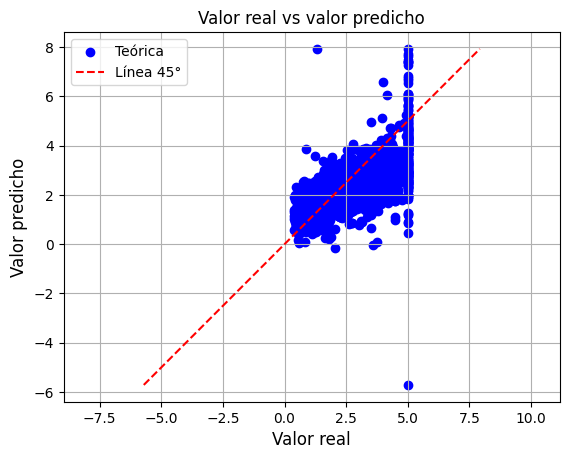

In [14]:

import matplotlib.pyplot as plt
import numpy as np

# Predicción y línea teórica
ypred = reg.predict(X_test)  # Solo si es necesario
plt.scatter(Y_test, ypred, label='Teórica', color='blue')
min_val = min(np.min(Y_test), np.min(ypred))
max_val = max(np.max(Y_test), np.max(ypred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Línea 45°')

# Etiquetas y leyenda
plt.xlabel('Valor real', fontsize=12)
plt.ylabel('Valor predicho', fontsize=12)
plt.title('Valor real vs valor predicho')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()



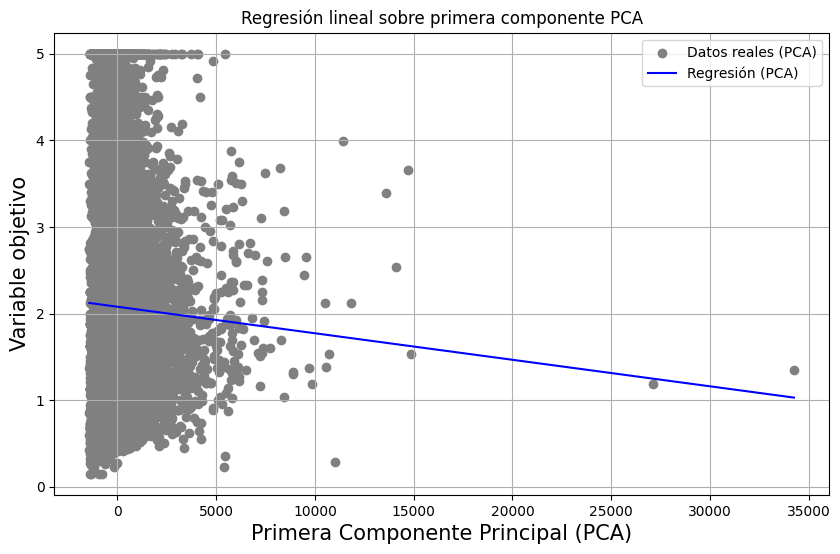

In [15]:

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Paso 1: Reducir X_train a 1 dimensión con PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_train)

# Paso 3: Entrenar regresión lineal sobre componente principal
reg = LinearRegression()
reg.fit(X_pca, Y_train)

# Predicción
y_pred = reg.predict(X_pca)

# Ordenar para graficar correctamente
sorted_idx = np.argsort(X_pca.ravel())
X_sorted = X_pca.ravel()[sorted_idx]
y_sorted = y_pred[sorted_idx]

# Paso 4: Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X_pca, Y_train, label='Datos reales (PCA)', color='gray')
plt.plot(X_sorted, y_sorted, label='Regresión (PCA)', color='blue')

plt.xlabel('Primera Componente Principal (PCA)', fontsize=15)
plt.ylabel('Variable objetivo', fontsize=15)
plt.legend()
plt.title('Regresión lineal sobre primera componente PCA')
plt.grid(True)
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error

# Predicciones en el test
X_test_pca = pca.transform(X_test)
y_test_pred = reg.predict(X_test_pca)

# Calcular ECM
mse = mean_squared_error(Y_test, y_test_pred)
print("Error Cuadrático Medio (MSE):", mse)
print(f'En promedio el test erra por U$D {np.sqrt(mse)*100000:,.2f}')

R2 = reg.score(ypred,Y_test)
print(f'ruido = {R2}')

Error Cuadrático Medio (MSE): 1.3038942155847684
En promedio el test erra por U$D 114,188.19
ruido = -0.0018175120778942677


**Se puede ver como se estima relativamente bien el valor promedio de las casas con un ruido bajo**

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
y = df[["Population"]]
X = df.drop(columns=["Population"])
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2)
reg = LinearRegression()
reg.fit(X_train,Y_train)
estimated = [reg.intercept_, reg.coef_]
print(estimated)

[array([2406.39986717]), array([[ -1.07623983, -28.78694482, -74.30572248, 133.40294935,
          7.14784385,  36.96396842]])]


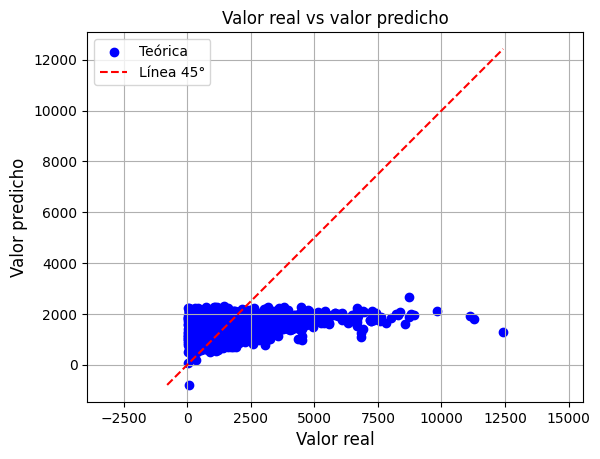

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Predicción y línea teórica
ypred = reg.predict(X_test)  # Solo si es necesario
plt.scatter(Y_test, ypred, label='Teórica', color='blue')
min_val = min(np.min(Y_test), np.min(ypred))
max_val = max(np.max(Y_test), np.max(ypred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Línea 45°')

# Etiquetas y leyenda
plt.xlabel('Valor real', fontsize=12)
plt.ylabel('Valor predicho', fontsize=12)
plt.title('Valor real vs valor predicho')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

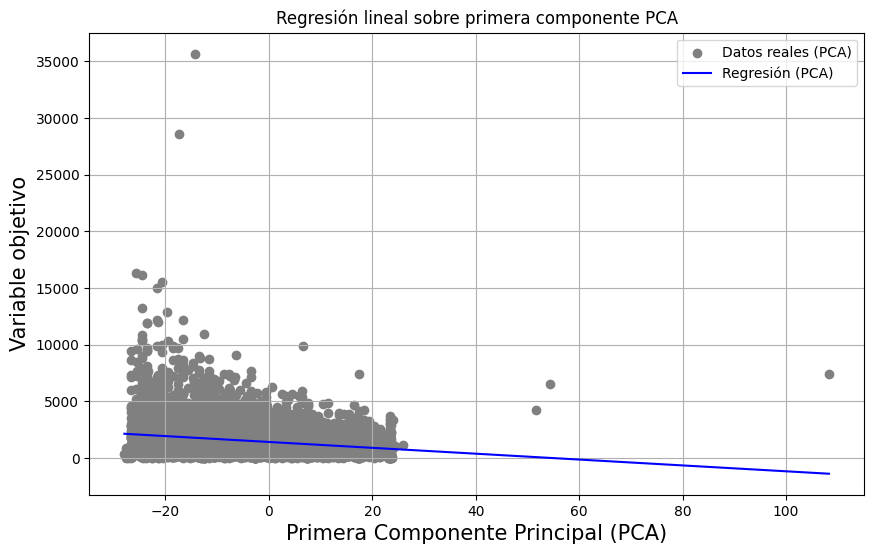

In [19]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Paso 1: Reducir X_train a 1 dimensión con PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_train)

# Paso 3: Entrenar regresión lineal sobre componente principal
reg = LinearRegression()
reg.fit(X_pca, Y_train)

# Predicción
y_pred = reg.predict(X_pca)

# Ordenar para graficar correctamente
sorted_idx = np.argsort(X_pca.ravel())
X_sorted = X_pca.ravel()[sorted_idx]
y_sorted = y_pred[sorted_idx]

# Paso 4: Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X_pca, Y_train, label='Datos reales (PCA)', color='gray')
plt.plot(X_sorted, y_sorted, label='Regresión (PCA)', color='blue')

plt.xlabel('Primera Componente Principal (PCA)', fontsize=15)
plt.ylabel('Variable objetivo', fontsize=15)
plt.legend()
plt.title('Regresión lineal sobre primera componente PCA')
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import mean_squared_error

# Predicciones en el test
X_test_pca = pca.transform(X_test)
y_test_pred = reg.predict(X_test_pca)

# Calcular ECM
mse = mean_squared_error(Y_test, y_test_pred)
print("Error Cuadrático Medio (MSE):", mse)
print(f'En promedio el test erra por  {np.sqrt(mse):,.0f} habitantes')

R2 = reg.score(ypred,Y_test)
print(f'ruido = {R2}')

Error Cuadrático Medio (MSE): 1159695.0744076667
En promedio el test erra por  1,077 habitantes
ruido = -1119.8340411525498


**En cambio los otros valores son malos para estimar la poblacion del bloque, logico sabiendo que son datos que no definen poblaciones**

***Hago una regresion simple para comparar el valor medio de un hogar unicamente con la edad de la casa***

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
y = df[["MedHouseVal"]]
X = df[["HouseAge"]]
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2)
reg = LinearRegression()
reg.fit(X_train,Y_train)
estimated = [reg.intercept_, reg.coef_]
print(estimated)

[array([1.81080883]), array([[0.00923866]])]


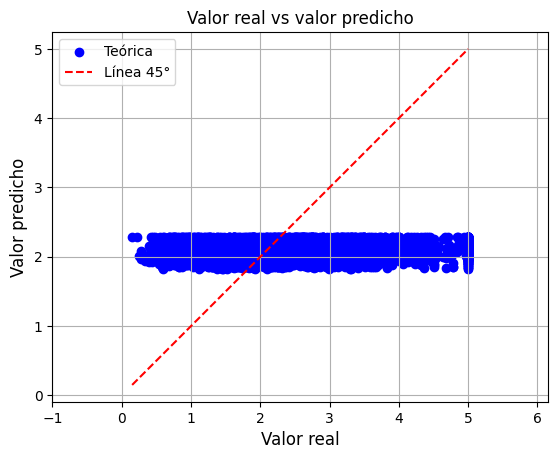

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Predicción y línea teórica
ypred = reg.predict(X_test)  # Solo si es necesario
plt.scatter(Y_test, ypred, label='Teórica', color='blue')
min_val = min(np.min(Y_test), np.min(ypred))
max_val = max(np.max(Y_test), np.max(ypred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Línea 45°')

# Etiquetas y leyenda
plt.xlabel('Valor real', fontsize=12)
plt.ylabel('Valor predicho', fontsize=12)
plt.title('Valor real vs valor predicho')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

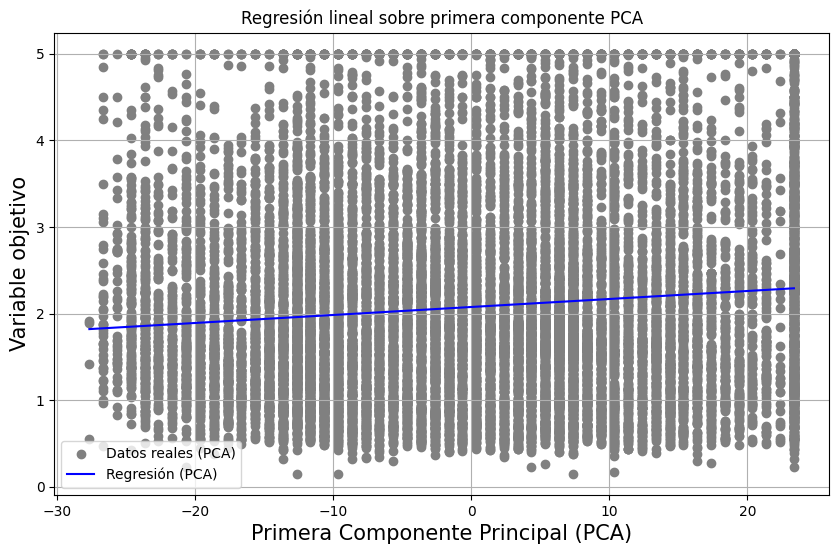

In [23]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Paso 1: Reducir X_train a 1 dimensión con PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_train)

# Paso 3: Entrenar regresión lineal sobre componente principal
reg = LinearRegression()
reg.fit(X_pca, Y_train)

# Predicción
y_pred = reg.predict(X_pca)

# Ordenar para graficar correctamente
sorted_idx = np.argsort(X_pca.ravel())
X_sorted = X_pca.ravel()[sorted_idx]
y_sorted = y_pred[sorted_idx]

# Paso 4: Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X_pca, Y_train, label='Datos reales (PCA)', color='gray')
plt.plot(X_sorted, y_sorted, label='Regresión (PCA)', color='blue')

plt.xlabel('Primera Componente Principal (PCA)', fontsize=15)
plt.ylabel('Variable objetivo', fontsize=15)
plt.legend()
plt.title('Regresión lineal sobre primera componente PCA')
plt.grid(True)
plt.show()

In [24]:
from sklearn.metrics import mean_squared_error

# Predicciones en el test
X_test_pca = pca.transform(X_test)
y_test_pred = reg.predict(X_test_pca)

# Calcular ECM
mse = mean_squared_error(Y_test, y_test_pred)
print("Error Cuadrático Medio (MSE):", mse)
print(f'En promedio el test erra por U$D {np.sqrt(mse)*100000:,.2f}')

R2 = reg.score(ypred,Y_test)
print(f'ruido = {R2}')

Error Cuadrático Medio (MSE): 1.2875986290695796
En promedio el test erra por U$D 113,472.40
ruido = -0.0019350446224248863


**No es mala forma de estimar**

In [25]:
y_muestra = muestra[["MedHouseVal"]]
X_muestra = muestra.drop(columns=["MedHouseVal"])
X_muestra_train,X_muestra_test,Y_muestra_train,Y_muestra_test = train_test_split(X_muestra,y_muestra,test_size=0.2)
reg = LinearRegression()
reg.fit(X_muestra_train,Y_muestra_train)
estimated = [reg.intercept_, reg.coef_]
print(estimated)

[array([-0.20450933]), array([[ 5.69259691e-01,  1.84739643e-02, -2.29741470e-01,
         1.13415097e+00,  9.73909420e-05, -2.01085260e-01]])]


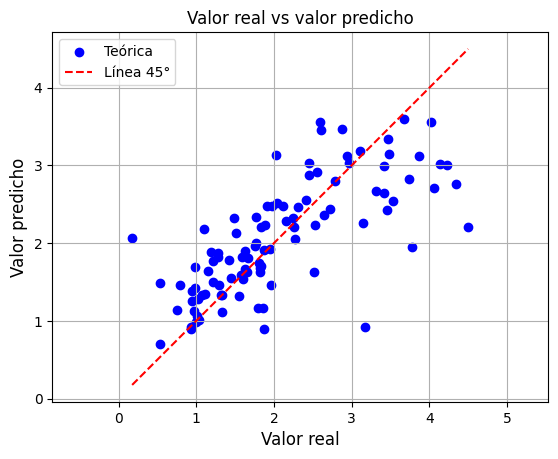

In [26]:
# Predicción y línea teórica
ypred_muestra = reg.predict(X_muestra_test)  # Solo si es necesario
plt.scatter(Y_muestra_test, ypred_muestra, label='Teórica', color='blue')
min_val = min(np.min(Y_muestra_test), np.min(ypred_muestra))
max_val = max(np.max(Y_muestra_test), np.max(ypred_muestra))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Línea 45°')

plt.xlabel('Valor real', fontsize=12)
plt.ylabel('Valor predicho', fontsize=12)
plt.title('Valor real vs valor predicho')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

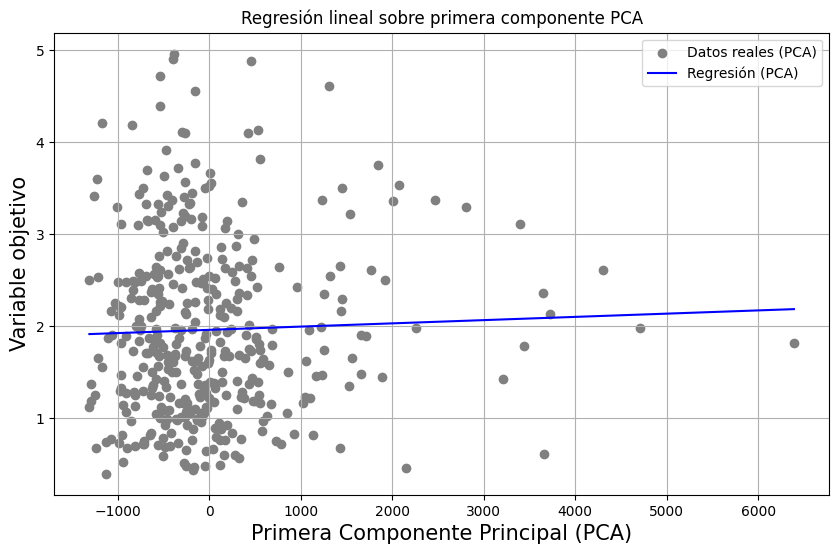

In [27]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Paso 1: Reducir X_train a 1 dimensión con PCA
pca = PCA(n_components=1)
X_muestra_pca = pca.fit_transform(X_muestra_train)

# Paso 3: Entrenar regresión lineal sobre componente principal
reg = LinearRegression()
reg.fit(X_muestra_pca, Y_muestra_train)

# Predicción
y_pred = reg.predict(X_muestra_pca)

# Ordenar para graficar correctamente
sorted_idx = np.argsort(X_muestra_pca.ravel())
X_sorted = X_muestra_pca.ravel()[sorted_idx]
y_sorted = y_pred[sorted_idx]

# Paso 4: Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X_muestra_pca, Y_muestra_train, label='Datos reales (PCA)', color='gray')
plt.plot(X_sorted, y_sorted, label='Regresión (PCA)', color='blue')

plt.xlabel('Primera Componente Principal (PCA)', fontsize=15)
plt.ylabel('Variable objetivo', fontsize=15)
plt.legend()
plt.title('Regresión lineal sobre primera componente PCA')
plt.grid(True)
plt.show()

In [28]:
from sklearn.metrics import mean_squared_error

# Predicciones en el test
X_test_pca = pca.transform(X_muestra_test)
y_test_pred = reg.predict(X_test_pca)

# Calcular ECM
mse = mean_squared_error(Y_muestra_test, y_test_pred)
print("Error Cuadrático Medio (MSE):", mse)
print(f'En promedio el test erra por U$D {np.sqrt(mse)*100000:,.2f}')

R2 = reg.score(ypred,Y_test)
print(f'ruido = {R2}')

Error Cuadrático Medio (MSE): 1.0120013689240601
En promedio el test erra por U$D 100,598.28
ruido = -0.004790258046825535


**Se ve como el test aplicado a esta muestra es mas efectivo que el aplicado a la poblacion (no siempre va a ser asi)**